In [298]:
import pandas as pd
movies = pd.read_csv('../data/tmdb_5000_movies.csv')  
credits = pd.read_csv('../data/tmdb_5000_credits.csv')


In [299]:
movies.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [300]:
credits.head(2)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [301]:
credits.rename(columns={"movie_id":"id"}, inplace=True)

In [302]:
movies.shape

(4803, 20)

In [303]:
credits.shape

(4803, 4)

In [304]:
movies_merged = pd.merge(movies, credits, on='id', how='inner')

In [305]:
movies_merged.shape

(4803, 23)

In [306]:
movies_merged.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [307]:
movies_merged.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title_x                    0
vote_average               0
vote_count                 0
title_y                    0
cast                       0
crew                       0
dtype: int64

In [308]:
movies_merged.drop(columns=["title_y", "title_x"], inplace=True)

In [309]:
movies_merged['homepage'] = movies_merged['homepage'].fillna('unknown')

In [310]:
movies_merged.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,release_date,revenue,runtime,spoken_languages,status,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [311]:
movies_merged.shape

(4803, 21)

In [312]:
movies_merged.isnull().sum()

budget                    0
genres                    0
homepage                  0
id                        0
keywords                  0
original_language         0
original_title            0
overview                  3
popularity                0
production_companies      0
production_countries      0
release_date              1
revenue                   0
runtime                   2
spoken_languages          0
status                    0
tagline                 844
vote_average              0
vote_count                0
cast                      0
crew                      0
dtype: int64

In [313]:
missing_overview = movies_merged[movies_merged['overview'].isnull()]
print(f"Found {len(missing_overview)} rows with missing overview")
print(missing_overview[['original_title']])

Found 3 rows with missing overview
                                  original_title
2656  Chiamatemi Francesco - Il Papa della gente
4140                 To Be Frank, Sinatra at 100
4431                                 Food Chains


In [314]:
movies_merged = movies_merged.dropna(subset=['overview'])

In [315]:
print(f"\nNew shape: {movies_merged.shape}")
print(f"Remaining nulls in overview: {movies_merged['overview'].isnull().sum()}")


New shape: (4800, 21)
Remaining nulls in overview: 0


In [316]:
missing_overview = movies_merged[movies_merged['release_date'].isnull()]
print(f"Found {len(missing_overview)} rows with missing overview")
print(missing_overview[['original_title','release_date']])

Found 1 rows with missing overview
                  original_title release_date
4553  America Is Still the Place          NaN


In [317]:
movies_merged = movies_merged.dropna(subset=['release_date'])

In [318]:
movies_merged['tagline'] = movies_merged['tagline'].fillna('')

In [319]:
movies_merged.isnull().sum()

budget                  0
genres                  0
homepage                0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
vote_average            0
vote_count              0
cast                    0
crew                    0
dtype: int64

In [320]:
movies_merged.shape

(4799, 21)

In [321]:
movies_merged.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.799000e+03,4799.000000,4799.000000,4.799000e+03,4799.000000,4799.000000,4799.000000
mean,2.906593e+07,56899.920192,21.509884,8.232920e+07,106.903105,6.094186,690.789123
std,4.073251e+07,88236.500208,31.824074,1.629076e+08,22.561305,1.188340,1234.941795
min,0.000000e+00,5.000000,0.000372,0.000000e+00,0.000000,0.000000,0.000000
25%,8.000000e+05,9012.500000,4.685547,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14623.000000,12.929525,1.918402e+07,103.000000,6.200000,236.000000
75%,4.000000e+07,58461.500000,28.350728,9.295652e+07,118.000000,6.800000,737.500000
max,3.800000e+08,447027.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [322]:
budget_movies = (movies_merged["budget"] == 0).sum()

revenue_movies = (movies_merged["revenue"] == 0).sum()

runtime_movies = (movies_merged["runtime"] == 0).sum()

print(budget_movies)
print(revenue_movies)
print(runtime_movies)

1036
1423
34


array([[<Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'revenue'}>],
       [<Axes: title={'center': 'runtime'}>, <Axes: >]], dtype=object)

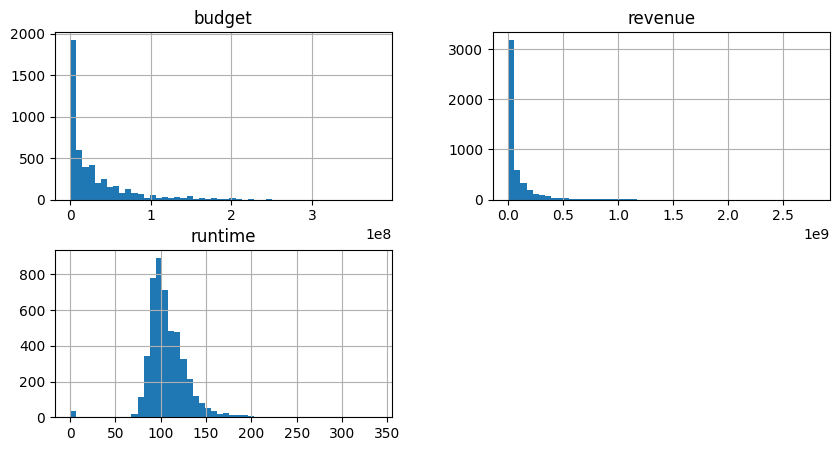

In [323]:
movies_merged[["budget","revenue","runtime"]].hist(figsize=(10,5), bins=50)

In [324]:
import numpy as np

movies_merged[['budget','revenue','runtime']] = movies_merged[['budget','revenue','runtime']].replace(0, np.nan)
movies_merged[['budget','revenue','runtime']].isna().sum()

budget     1036
revenue    1423
runtime      34
dtype: int64

In [325]:
movies_merged['budget'].isna().mean()   # fraction missing
movies_merged['revenue'].isna().mean()

np.float64(0.2965201083559075)

In [326]:
keep_cols = [
    'original_title',           
    'overview',        
    'genres',          
    'keywords',        
    'cast',            
    'crew'             
]

movies_final = movies_merged[keep_cols].copy()

movies_final = movies_final.rename(columns={"original_title": "title"})

movies_final.head()

,title,overview,genres,keywords,cast,crew
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [327]:
import ast

def parse_names(json_text):

    try:

        data = ast.literal_eval(json_text)

        names = [item['name'] for item in data]
        return names
    except:
        return []  

# Apply to each column
movies_final['genres'] = movies_final['genres'].apply(parse_names)
movies_final['keywords'] = movies_final['keywords'].apply(parse_names)
movies_final['cast'] = movies_final['cast'].apply(parse_names)


def get_director(crew_json):
    try:
        crew_list = ast.literal_eval(crew_json)
        for person in crew_list:
            if person.get('job') == 'Director':
                return [person['name']]  
        return []
    except:
        return []

movies_final['director'] = movies_final['crew'].apply(get_director)

# Drop original crew column
movies_final.drop(columns=['crew'], inplace=True)


movies_final.head()

,title,overview,genres,keywords,cast,director
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron]
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski]
2,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",[Sam Mendes]
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...",[Christopher Nolan]
4,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",[Andrew Stanton]


In [328]:
print(movies_final['genres'].iloc[0])
print(movies_final['cast'].iloc[0])

['Action', 'Adventure', 'Fantasy', 'Science Fiction']
['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Dileep Rao', 'Matt Gerald', 'Sean Anthony Moran', 'Jason Whyte', 'Scott Lawrence', 'Kelly Kilgour', 'James Patrick Pitt', 'Sean Patrick Murphy', 'Peter Dillon', 'Kevin Dorman', 'Kelson Henderson', 'David Van Horn', 'Jacob Tomuri', 'Michael Blain-Rozgay', 'Jon Curry', 'Luke Hawker', 'Woody Schultz', 'Peter Mensah', 'Sonia Yee', 'Jahnel Curfman', 'Ilram Choi', 'Kyla Warren', 'Lisa Roumain', 'Debra Wilson', 'Chris Mala', 'Taylor Kibby', 'Jodie Landau', 'Julie Lamm', 'Cullen B. Madden', 'Joseph Brady Madden', 'Frankie Torres', 'Austin Wilson', 'Sara Wilson', 'Tamica Washington-Miller', 'Lucy Briant', 'Nathan Meister', 'Gerry Blair', 'Matthew Chamberlain', 'Paul Yates', 'Wray Wilson', 'James Gaylyn', 'Melvin Leno Clark III', 'Carvon Futrell', 'Brandon Jelkes', 'Mica

In [329]:
def collapse_spaces(name_list):
    if not isinstance(name_list, list):
        return []
    return [name.replace(" ", "") for name in name_list]

movies_final['genres'] = movies_final['genres'].apply(collapse_spaces)
movies_final['keywords'] = movies_final['keywords'].apply(collapse_spaces)
movies_final['cast'] = movies_final['cast'].apply(collapse_spaces)
movies_final['director'] = movies_final['director'].apply(collapse_spaces)

In [330]:
movies_final.head()

,title,overview,genres,keywords,cast,director
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron]
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley, Ste...",[GoreVerbinski]
2,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux, Ralp...",[SamMendes]
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman, Anne...",[ChristopherNolan]
4,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton, Wi...",[AndrewStanton]


In [331]:
print(movies_final['genres'].iloc[0])
print(movies_final['cast'].iloc[0])

['Action', 'Adventure', 'Fantasy', 'ScienceFiction']
['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver', 'StephenLang', 'MichelleRodriguez', 'GiovanniRibisi', 'JoelDavidMoore', 'CCHPounder', 'WesStudi', 'LazAlonso', 'DileepRao', 'MattGerald', 'SeanAnthonyMoran', 'JasonWhyte', 'ScottLawrence', 'KellyKilgour', 'JamesPatrickPitt', 'SeanPatrickMurphy', 'PeterDillon', 'KevinDorman', 'KelsonHenderson', 'DavidVanHorn', 'JacobTomuri', 'MichaelBlain-Rozgay', 'JonCurry', 'LukeHawker', 'WoodySchultz', 'PeterMensah', 'SoniaYee', 'JahnelCurfman', 'IlramChoi', 'KylaWarren', 'LisaRoumain', 'DebraWilson', 'ChrisMala', 'TaylorKibby', 'JodieLandau', 'JulieLamm', 'CullenB.Madden', 'JosephBradyMadden', 'FrankieTorres', 'AustinWilson', 'SaraWilson', 'TamicaWashington-Miller', 'LucyBriant', 'NathanMeister', 'GerryBlair', 'MatthewChamberlain', 'PaulYates', 'WrayWilson', 'JamesGaylyn', 'MelvinLenoClarkIII', 'CarvonFutrell', 'BrandonJelkes', 'MicahMoch', 'HanniyahMuhammad', 'ChristopherNolen', 'ChristaOliver',

In [332]:
movies_final['overview'] = movies_final['overview'].fillna('')

movies_final['overview'] = movies_final['overview'].apply(lambda x: x.split())

movies_final['overview']

0       [In, the, 22nd, century,, a, paraplegic, Marin...
1       [Captain, Barbossa,, long, believed, to, be, d...
2       [A, cryptic, message, from, Bond’s, past, send...
3       [Following, the, death, of, District, Attorney...
4       [John, Carter, is, a, war-weary,, former, mili...
                              ...                        
4798    [El, Mariachi, just, wants, to, play, his, gui...
4799    [A, newlywed, couple's, honeymoon, is, upended...
4800    ["Signed,, Sealed,, Delivered", introduces, a,...
4801    [When, ambitious, New, York, attorney, Sam, is...
4802    [Ever, since, the, second, grade, when, he, fi...
Name: overview, Length: 4799, dtype: object

In [361]:
def create_tags(row):
    tags = []
    tags.extend(row['genres'] * 4)
    tags.extend(row['keywords'] * 2)
    tags.extend(row['cast'][:3])
    tags.extend(row['director'] * 2)
    if isinstance(row['overview'], list):
        tags.extend(row['overview'][:50])
    return " ".join(tags).lower()

movies_final['tags'] = movies_final.apply(create_tags, axis=1)

# Add id
movies_final['id'] = movies_merged['id'] 


movies_df = movies_final[['id', 'title', 'tags']].copy()  

movies_df = movies_df.reset_index(drop=True)

# Create vectors from movies_df (not movies_final!)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = CountVectorizer(max_features=5000, stop_words='english')
tag_vectors = vectorizer.fit_transform(movies_df['tags'])  # Use movies_df!

# Calculate similarity
similarity = cosine_similarity(tag_vectors)

# Test function using movies_df
def get_recommendations(movie_title, num=5):
    idx = movies_df[movies_df['title'] == movie_title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:num+1]
    
    print(f"\n🎬 Because you watched: {movie_title}")
    print("-" * 50)
    for i, (movie_idx, score) in enumerate(scores):
        movie = movies_df.iloc[movie_idx]['title']
        print(f"{i+1}. {movie} (similarity: {score:.3f})")

# Test Pulp Fiction
get_recommendations("Pulp Fiction")

# Save to models folder
import pickle
import os

if not os.path.exists('models'):
    os.makedirs('models')
    print("Created 'models'")

# Save using correct paths
pickle.dump(movies_df, open('../models/movies.pkl', 'wb'))
pickle.dump(similarity, open('../models/similarity.pkl', 'wb'))

print("Saved successfully!")


🎬 Because you watched: Pulp Fiction
--------------------------------------------------
1. Hodejegerne (similarity: 0.572)
2. Snabba Cash (similarity: 0.524)
3. Blood Ties (similarity: 0.515)
4. Suspect Zero (similarity: 0.507)
5. 放‧逐 (similarity: 0.501)
✅ Saved successfully!


In [362]:
print(f"Shape: {tag_vectors.shape}")
print(f"Rows (movies): {tag_vectors.shape[0]}")
print(f"Columns (words): {tag_vectors.shape[1]}")
print(f"Total words in vocabulary: {len(vectorizer.get_feature_names_out())}")

# 4. See example words
print("\nSample words:", vectorizer.get_feature_names_out()[:40])

Shape: (4799, 5000)
Rows (movies): 4799
Columns (words): 5000
Total words in vocabulary: 5000

Sample words: ['000' '10' '100' '11' '12' '13' '14' '15' '16' '17' '18' '18th'
 '18thcentury' '19' '1910s' '1930s' '1940s' '1950s' '1960s' '1970s'
 '1980s' '1990s' '19th' '19thcentury' '20' '200' '20th' '21stcentury' '24'
 '25' '30' '3d' '40' '50' '60s' 'aaron' 'aaroneckhart' 'abandoned'
 'abducted' 'abigailbreslin']


In [363]:

print(vectorizer.get_feature_names_out()[:50]) # First 50 words alphabetically

['000' '10' '100' '11' '12' '13' '14' '15' '16' '17' '18' '18th'
 '18thcentury' '19' '1910s' '1930s' '1940s' '1950s' '1960s' '1970s'
 '1980s' '1990s' '19th' '19thcentury' '20' '200' '20th' '21stcentury' '24'
 '25' '30' '3d' '40' '50' '60s' 'aaron' 'aaroneckhart' 'abandoned'
 'abducted' 'abigailbreslin' 'ability' 'able' 'abrams' 'abuse' 'abusive'
 'academy' 'accept' 'accepts' 'access' 'accident']


In [364]:

movie_index = 0 
distances = similarity[movie_index]

for i in range(5):
    print(f"{movies_final['title'].iloc[i]}: {distances[i]:.3f}")

Avatar: 1.000
Pirates of the Caribbean: At World's End: 0.335
Spectre: 0.261
The Dark Knight Rises: 0.100
John Carter: 0.443


In [365]:
# 1. FIND your movies
movies_to_check = ['Avengers', 'Iron Man', 'Taxi Driver', 'The Dark Knight', 'The Wizard of Oz']

for movie in movies_to_check:
    matches = movies_df[movies_df['title'].str.contains(movie, case=False, na=False)]
    if not matches.empty:
        for idx, title in zip(matches.index, matches['title']):
            print(f"Index {idx}: {title}")
    else:
        print(f"x '{movie}' not found")

Index 7: Avengers: Age of Ultron
Index 16: The Avengers
Index 31: Iron Man 3
Index 68: Iron Man
Index 79: Iron Man 2
Index 4335: Taxi Driver
Index 3: The Dark Knight Rises
Index 65: The Dark Knight
Index 3853: Batman: The Dark Knight Returns, Part 2
Index 3985: The Wizard of Oz


In [366]:

indices = [4335, 16, 68, 3, 3985]  

print("Similarity Matrix (1.0 = identical):")
for i in range(len(indices)):
    for j in range(len(indices)):
        sim = similarity[indices[i]][indices[j]]
        movie1 = movies_final.iloc[indices[i]]['title']
        movie2 = movies_final.iloc[indices[j]]['title']
        print(f"{movie1} ↔ {movie2}: {sim:.3f}")
    print()

Similarity Matrix (1.0 = identical):
Taxi Driver ↔ Taxi Driver: 1.000
Taxi Driver ↔ The Avengers: 0.037
Taxi Driver ↔ Iron Man: 0.040
Taxi Driver ↔ The Dark Knight Rises: 0.304
Taxi Driver ↔ The Wizard of Oz: 0.000

The Avengers ↔ Taxi Driver: 0.037
The Avengers ↔ The Avengers: 1.000
The Avengers ↔ Iron Man: 0.656
The Avengers ↔ The Dark Knight Rises: 0.139
The Avengers ↔ The Wizard of Oz: 0.146

Iron Man ↔ Taxi Driver: 0.040
Iron Man ↔ The Avengers: 0.656
Iron Man ↔ Iron Man: 1.000
Iron Man ↔ The Dark Knight Rises: 0.149
Iron Man ↔ The Wizard of Oz: 0.140

The Dark Knight Rises ↔ Taxi Driver: 0.304
The Dark Knight Rises ↔ The Avengers: 0.139
The Dark Knight Rises ↔ Iron Man: 0.149
The Dark Knight Rises ↔ The Dark Knight Rises: 1.000
The Dark Knight Rises ↔ The Wizard of Oz: 0.025

The Wizard of Oz ↔ Taxi Driver: 0.000
The Wizard of Oz ↔ The Avengers: 0.146
The Wizard of Oz ↔ Iron Man: 0.140
The Wizard of Oz ↔ The Dark Knight Rises: 0.025
The Wizard of Oz ↔ The Wizard of Oz: 1.000



In [367]:
casino = movies_df[movies_df['title'] == 'Casino']['tags'].iloc[0]
goodfellas = movies_df[movies_df['title'] == 'GoodFellas']['tags'].iloc[0]

print("Casino tags length:", len(casino.split()))
print("GoodFellas tags length:", len(goodfellas.split()))


casino_words = set(casino.split())
goodfellas_words = set(goodfellas.split())
common = casino_words.intersection(goodfellas_words)
print(f"\nCommon words ({len(common)}):", list(common)[:10])

Casino tags length: 38
GoodFellas tags length: 88

Common words (10): ['martinscorsese', 'of', 'robertdeniro', 'drama', '1970s', 'crime', 'and', 'the', 'joepesci', 'mafia']


In [369]:
# Test with Scorsese movies
test_movies = ['GoodFellas', 'Casino', 'The Departed', 'Hugo']

for movie in test_movies:
    idx = movies_final[movies_final['title'] == movie].index[0]
    print(f"\n{movie} tags (first 100 chars):")
    print(movies_final.iloc[idx]['tags'][:100])


GoodFellas tags (first 100 chars):
drama crime drama crime drama crime drama crime prison basedonnovel florida 1970s massmurder irish-a

Casino tags (first 100 chars):
drama crime drama crime drama crime drama crime poker drugabuse 1970s overdose illegalprostitution p

The Departed tags (first 100 chars):
drama thriller crime drama thriller crime drama thriller crime drama thriller crime undercover bosto

Hugo tags (first 100 chars):
adventure drama family adventure drama family adventure drama family adventure drama family library 


In [370]:
def get_recommendations(movie_title, num=5):
    idx = movies_final[movies_final['title'] == movie_title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:num+1]
    
    print(f"\n🎬 Because you watched: {movie_title}")
    print("-" * 50)
    for i, (movie_idx, score) in enumerate(scores):
        movie = movies_final.iloc[movie_idx]['title']
        print(f"{i+1}. {movie} (similarity: {score:.3f})")

# 3. TEST 1: Scorsese crime films
print("=" * 60)
print("TEST 1: SCORSESE CRIME FILMS")
print("=" * 60)
get_recommendations("GoodFellas")
get_recommendations("Casino")
get_recommendations("The Departed")

print("\n" + "=" * 60)
print("TEST 2: MIXED GENRES")
print("=" * 60)
get_recommendations("Toy Story")
get_recommendations("The Dark Knight")
get_recommendations("Pulp Fiction")

# 5. TEST 3: Should be different!
print("\n" + "=" * 60)
print("TEST 3: SHOULD BE UNIQUE")
print("=" * 60)
get_recommendations("The Wizard of Oz")
get_recommendations("2001: A Space Odyssey")

TEST 1: SCORSESE CRIME FILMS

🎬 Because you watched: GoodFellas
--------------------------------------------------
1. Black Mass (similarity: 0.480)
2. Casino (similarity: 0.466)
3. Mi America (similarity: 0.442)
4. Deadline - U.S.A. (similarity: 0.442)
5. The Funeral (similarity: 0.440)

🎬 Because you watched: Casino
--------------------------------------------------
1. Mi America (similarity: 0.646)
2. Deadline - U.S.A. (similarity: 0.608)
3. Better Luck Tomorrow (similarity: 0.587)
4. Blood Ties (similarity: 0.585)
5. Rounders (similarity: 0.582)

🎬 Because you watched: The Departed
--------------------------------------------------
1. Donnie Brasco (similarity: 0.653)
2. Nueve Reinas (similarity: 0.595)
3. Compliance (similarity: 0.591)
4. Blood Ties (similarity: 0.577)
5. Snabba Cash (similarity: 0.572)

TEST 2: MIXED GENRES

🎬 Because you watched: Toy Story
--------------------------------------------------
1. Toy Story 3 (similarity: 0.644)
2. Toy Story 2 (similarity: 0.625)
3. 

In [371]:
# Check what's actually in Pulp Fiction's original columns
pulp_row = movies_final[movies_final['title'] == 'Pulp Fiction'].iloc[0]

print("RAW DATA FOR PULP FICTION:")
print(f"Genres: {pulp_row['genres']}")
print(f"Keywords: {pulp_row['keywords']}")
print(f"Cast: {pulp_row['cast'][:5]}")
print(f"Director: {pulp_row['director']}")
print(f"Overview (first 100 chars): {str(pulp_row['overview'])[:100]}")

RAW DATA FOR PULP FICTION:
Genres: ['Thriller', 'Crime']
Keywords: ['transporter', 'brothel', 'drugdealer', 'boxer', 'massage', 'stolenmoney', 'crimeboss', 'dancecontest', 'junkyard', 'kamikaze', 'ambiguousending', 'briefcase', 'redemption', 'heirloom', 'pulpfiction', 'referencetoalgreen', 'theft', 'brutality']
Cast: ['JohnTravolta', 'SamuelL.Jackson', 'UmaThurman', 'BruceWillis', 'VingRhames']
Director: ['QuentinTarantino']
Overview (first 100 chars): ['A', 'burger-loving', 'hit', 'man,', 'his', 'philosophical', 'partner,', 'a', 'drug-addled', "gangs
